<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_11_desicion_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11: Árboles de desición


#Algoritmo CART (classification and regresion tree)

Se busca entrenar un modelo para categorizar la información encontrando la frontera de desición, permite tener una mejor interpretabilidad que las redes neuronales dado que se puede tener una represetancion grafica del proceso de desiscion secuencial.

- ref https://www.youtube.com/watch?v=kqaLlte6P6o&ab_channel=CodificandoBits
- Hand on Machine leargning




Dado un conjunto de caracteristicas se establece una condición que realiza
una particion binaria de los datos a clasificar repitiendo hasta encontrar
particiones lo más homogenea posible.




In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pylab as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
import graphviz
#from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree

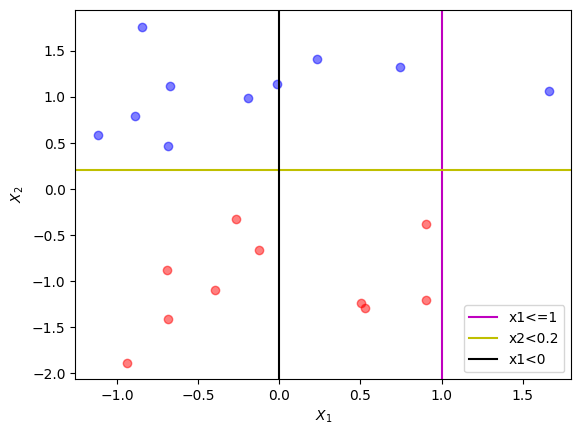

In [2]:

X0, y0 = make_classification(n_samples=20,
    n_features=2, n_redundant=0, n_informative=1, random_state=1,
    n_clusters_per_class=1)

#x=np.arange(-2, 3,1)
#x_,y_ = np.meshgrid(x,x)

fig, ax = plt.subplots()
ax.plot(X0[:,0][y0==0],X0[:,1][y0==0],"ro", alpha=0.5)
ax.plot(X0[:,0][y0==1],X0[:,1][y0==1],"bo", alpha=0.5)
#ax.plot(x_,y_,"k.")

ax.axvline(x = 1, color = 'm', label="x1<=1")
ax.axhline(y = 0.2, color = 'y', label="x2<0.2")
ax.axvline(x = 0.0, color = 'k', label="x1<0")
#plt.legend(loc=3)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.show()


- Gini index


$G = 1 - (PC_1)^2 - (PC_2)^2$

$PC_1$: Probablidad categoria 1

$PC_2$: Probablidad categoria 2

Si :

- $G=0$ nodos puros, datos que pertenecen a una sola categoría

- Gini > 0 son nodos con impurezas, con mas de una categoría


La partición purpura  y amarilla del gráfico anterior representan nodos puros.

Mientras que la linea negra define:

- 7 puntos son de color azul.

- 6 puntos de color rojo.

$G = 1 - (7/13)^{2} - (6/13)^{2}$

mientrás que la ponderacion viene dada por:

$m = (13/20+7/20)=1



No:

$G=1-(3/7)^{2}-(4/7)^{2}$
m = (3/20+4/20)


La funcion de coste, asocida al nodo padre:

$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right} $



# Algoritmo
1. Calcular todos los posibles condiciones.
2. Calcular los indices de Gini.
3. Encontrar la funcion de coste
4. Escoger la menor funcion de coste
5. Repetir.


# Actividad

1. Importar iris dataset
2. Generar una intuición respecto a iris dataset. Ver laboratorio anterior.
3. Dividir el *dataset* empleanto el metodo train_test_split de sklearn
4. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.
5. Para el clasificador analice el gráfico de desición:

```

https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

  fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
  graph=tree.plot_tree(clf,class_names = iris.target_names,\
                feature_names = iris.feature_names,\
                impurity=False, filled=True,rounded=True )

```

6. Características importantes.

```
clf.feature_importances_
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()
```

7. Fronteras de desición.



```
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Parameters
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

# Load data
iris = load_iris()

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Shuffle
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    # Standardize
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    plt.subplot(2, 3, pairidx + 1)
  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    cmap=plt.cm.Paired)

    plt.axis("tight")

plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend()
plt.show()
```


#Solucion

Ahora explicame de manera detallada los pasos del algoritmo
¡Excelente! Vamos a desglosar los pasos del algoritmo CART de manera detallada:

Pasos Detallados del Algoritmo CART
1. Calcular todas las posibles condiciones para la partición: Este es el punto de partida para encontrar la mejor división. Para cada característica (columna) en tus datos, el algoritmo identifica los posibles puntos de corte:

Para características numéricas: Se ordenan los valores únicos de la característica. Cada punto de corte candidato se establece generalmente como el punto medio entre dos valores consecutivos únicos. Por ejemplo, si una característica tiene valores únicos [1.0, 2.5, 3.0, 4.5], las posibles condiciones serían Característica <= 1.75, Característica <= 2.75, Característica <= 3.75.
Para características categóricas: Se exploran todas las posibles agrupaciones binarias de las categorías. Si una característica tiene categorías A, B, C, una condición podría ser Característica es 'A' o Característica es 'B' o 'C'. El objetivo es generar una lista exhaustiva de todas las posibles líneas de división (como las líneas verticales y horizontales en tu gráfico) que podrían separar los datos.
2. Calcular los índices de Gini para cada posible condición: Una vez que se tienen las posibles condiciones de partición, el algoritmo evalúa cómo de 'buenas' son estas divisiones. Para cada división candidata, se hace lo siguiente:

Divide el conjunto de datos: La condición divide el nodo actual en dos nodos hijos (por ejemplo, los puntos a la izquierda de la línea negra y los puntos a la derecha).
Calcula la impureza Gini para cada nodo hijo: Para cada uno de esos dos nodos hijos, se calcula el Índice de Gini. El Gini mide la probabilidad de clasificar erróneamente una muestra seleccionada al azar si esa muestra se clasifica de acuerdo con la distribución de las clases en ese nodo. Un Gini de 0 significa que el nodo es "puro" (todas las muestras pertenecen a la misma clase), y un Gini más alto indica mayor impureza.
G_hijo = 1 - Σ (PC_i)^2 (donde PC_i es la proporción de la clase i en ese nodo hijo).
3. Encontrar la función de coste (impureza ponderada) para cada división: Aquí es donde entra en juego la "ponderación" que mencionamos antes. Para cada división candidata, el algoritmo no solo considera la impureza de los nodos hijos, sino también cuántas muestras contiene cada hijo. La función de coste, o ganancia de información (basada en Gini en este caso), se calcula como la suma ponderada de los Gini de los nodos hijos:

J(división) = (m_izquierda / m_total) * G_izquierda + (m_derecha / m_total) * G_derecha
m_izquierda y m_derecha son el número de muestras en el nodo hijo izquierdo y derecho, respectivamente.
m_total es el número total de muestras en el nodo padre actual.
G_izquierda y G_derecha son los índices de Gini de los nodos hijos. Esta función de coste nos da una medida combinada de la impureza que resulta de esa división, teniendo en cuenta el tamaño de cada nodo hijo. El objetivo es minimizar este valor, buscando divisiones que resulten en nodos hijos lo más puros posible y con una buena distribución de datos.
4. Escoger la división (condición) con la menor función de coste: De todas las posibles condiciones de partición evaluadas en el paso 3, el algoritmo selecciona aquella que produce el menor valor de la función de coste. Esta es la división que, según el criterio de Gini, mejor separa las clases en el nodo actual. Esta condición se convierte en el "criterio de decisión" de ese nodo en el árbol.

5. Repetir el proceso recursivamente: Una vez que se ha encontrado la mejor división para un nodo, el algoritmo aplica el mismo proceso (pasos 1 a 4) de forma recursiva a cada uno de los nodos hijos resultantes. Este proceso de división continúa hasta que se cumple algún criterio de detención, como:

Los nodos se vuelven "puros" (Gini = 0).
El número de muestras en un nodo cae por debajo de un umbral mínimo.
El árbol alcanza una profundidad máxima predefinida.
No se puede encontrar una división que reduzca significativamente la impureza.
Este proceso iterativo construye el árbol de decisión rama por rama, buscando siempre la mejor división en cada punto para clasificar los datos de manera efectiva.

In [3]:
#!) Importar dataset
from sklearn.datasets import load_iris
iris = load_iris()
#2) Intuicion para recordar el dataset
print(iris.DESCR)
print(iris.data[:5])
print(iris.target[:5])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
#3)

from sklearn.model_selection import train_test_split
x = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1)


In [5]:
#4)
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

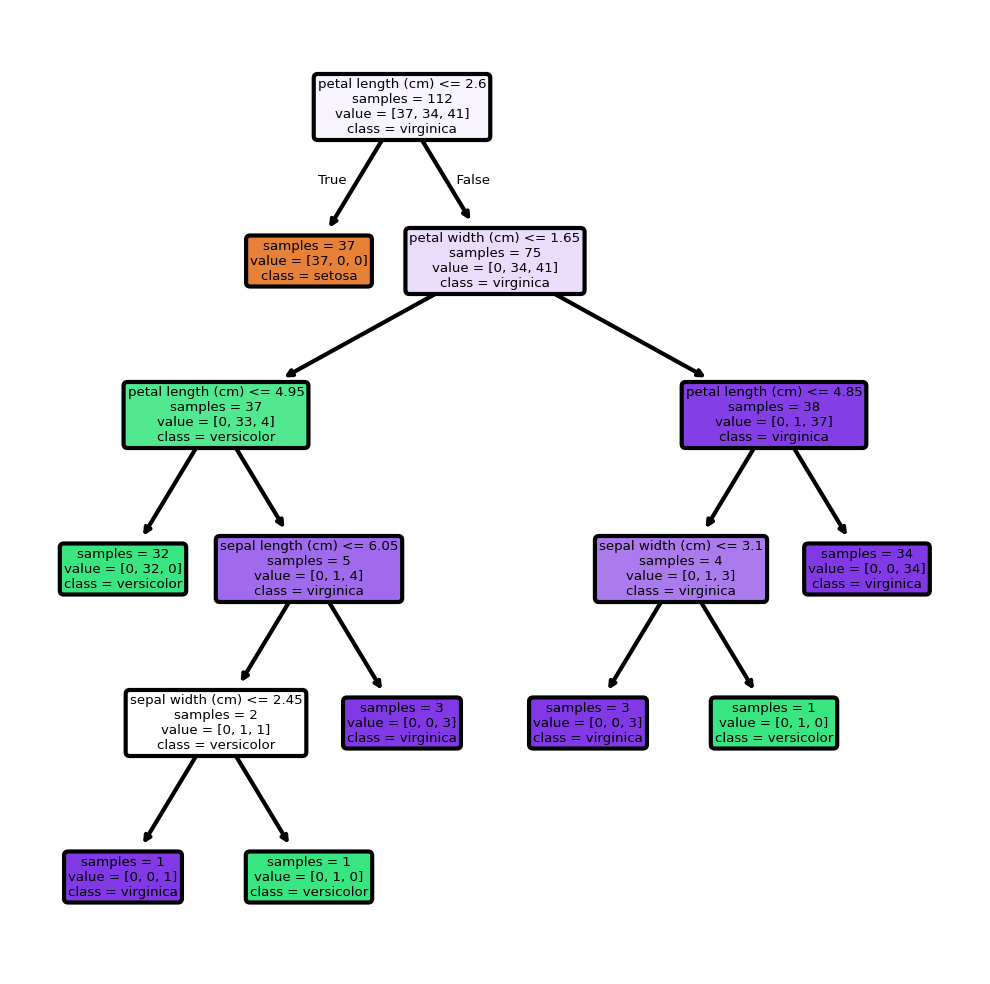

In [6]:
#5)
import matplotlib.pyplot as plt
from sklearn import tree

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
graph = tree.plot_tree(clf, class_names = iris.target_names, feature_names = iris.feature_names, impurity=False, filled=True,rounded=True)
plt.show()

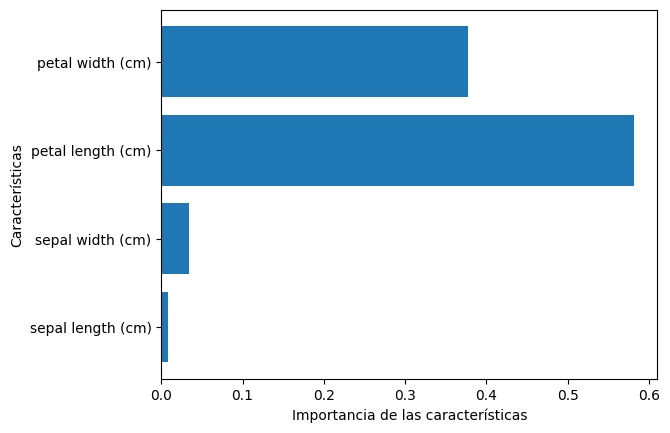

In [7]:
#6)
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()

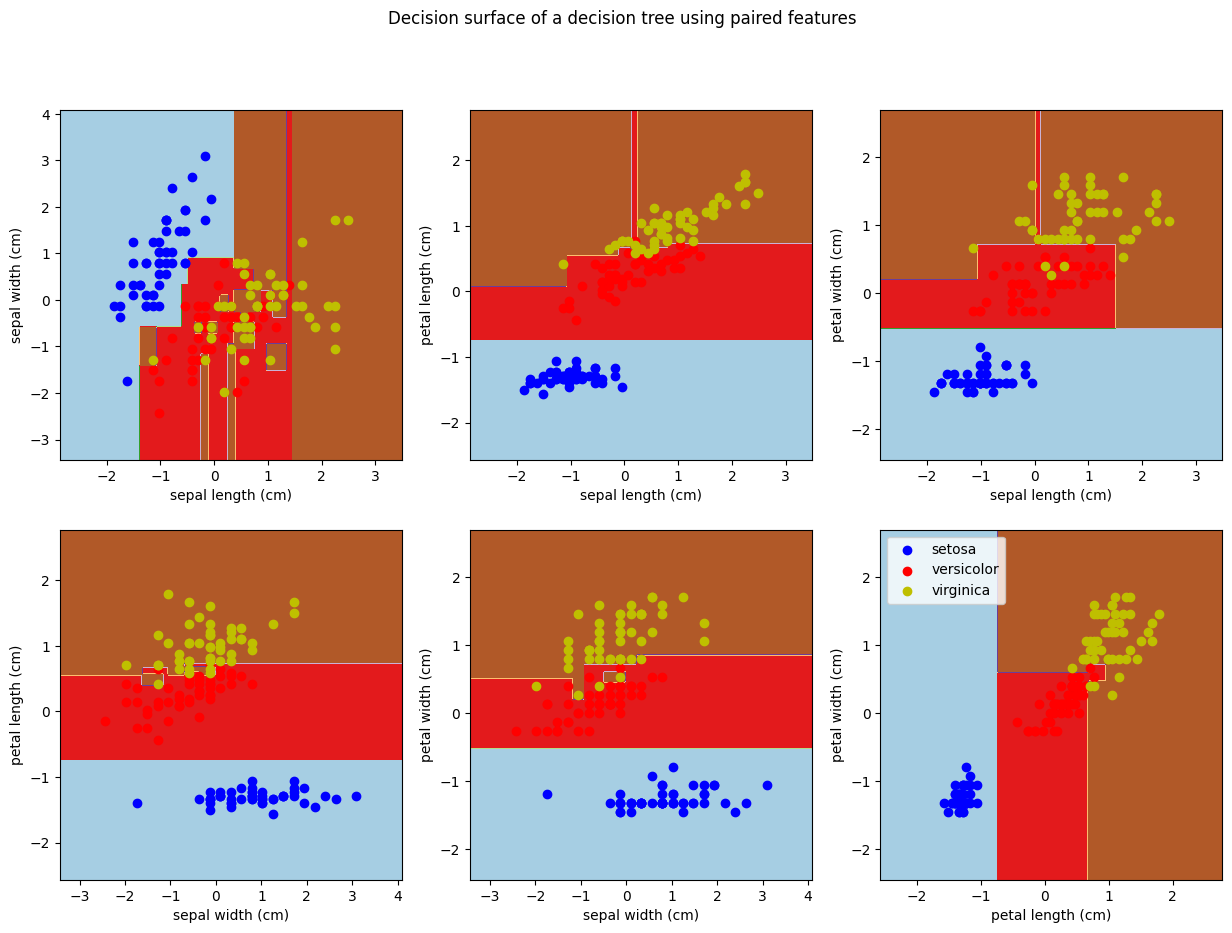

In [9]:
#7) Fronteras de desición.

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Parameters
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

# Load data
iris = load_iris()

fig = plt.figure(figsize=(15, 10))
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    X = iris.data[:, pair]
    y = iris.target

    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    clf = DecisionTreeClassifier().fit(X, y)

    plt.subplot(2, 3, pairidx + 1)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")


    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i])

    plt.axis("tight")

plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend()
plt.show()

Al final del notebook hay una celda con una actividad la cual contiene varios puntos, explicame cada punto y como solucionarlo
¡Excelente! La sección de 'Actividad' te guía a través de los pasos clave para trabajar con un árbol de decisión. Aquí te explico cada punto y cómo abordarlo, basándome en el código que ya está en la actividad:

Actividad Detallada:
Importar iris dataset:

Explicación: Este primer paso consiste en cargar el famoso conjunto de datos 'Iris' que viene preinstalado con scikit-learn. Este dataset es muy común para ejemplos de clasificación y contiene mediciones de pétalos y sépalos de tres especies diferentes de flores de iris.
Solución (código ya dado en el punto 7 de la actividad):
from sklearn.datasets import load_iris
iris = load_iris()
Generar una intuición respecto a iris dataset. Ver laboratorio anterior.

Explicación: Antes de construir un modelo, es fundamental entender los datos. Esto implica explorar las características (como el largo y ancho del sépalo y pétalo), las clases (las especies de iris) y cómo se distribuyen. El cuaderno te refiere a un laboratorio anterior, lo que sugiere que ya deberías haber realizado un Análisis Exploratorio de Datos (EDA) del Iris dataset. Puedes ver la descripción del dataset con print(iris.DESCR) y examinar las características y nombres de las clases con iris.feature_names y iris.target_names.
Solución: Aunque no hay un código explícito para 'generar intuición' en esta actividad, podrías usar comandos como print(iris.DESCR), print(iris.data[:5]), print(iris.target[:5]) para recordar su estructura.
Dividir el dataset empleando el método train_test_split de sklearn:

Explicación: Para evaluar correctamente el rendimiento de un modelo, es crucial dividir los datos en conjuntos de entrenamiento y prueba. El modelo se 'aprende' del conjunto de entrenamiento y luego se evalúa su capacidad para generalizar con datos que nunca ha visto, el conjunto de prueba. train_test_split te ayuda a hacer esta división de forma aleatoria.
**Solución (código a generar antes del punto 7): **
from sklearn.model_selection import train_test_split
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Puedes ajustar test_size para el porcentaje de datos de prueba
# random_state asegura que la división sea reproducible
Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier:

Explicación: Este es el núcleo del laboratorio. Aquí instanciarás un modelo de árbol de decisión y lo 'entrenarás' con tus datos de entrenamiento. El proceso de entrenamiento construirá el árbol encontrando las mejores divisiones según el algoritmo CART.
Solución (código a generar después del punto 3):
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42) # Puedes añadir hiperparámetros aquí, como max_depth
clf.fit(X_train, y_train)
Para el clasificador, analice el gráfico de decisión:

Explicación: Una de las grandes ventajas de los árboles de decisión es su interpretabilidad. sklearn.tree.plot_tree te permite visualizar la estructura del árbol que el modelo ha aprendido. Cada nodo representa una condición de división, y las ramas representan los resultados de esa condición. Puedes ver qué característica y qué valor se utilizan para dividir los datos en cada etapa.
Solución (código ya dado en la actividad):
import matplotlib.pyplot as plt
from sklearn import tree
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
graph=tree.plot_tree(clf,class_names = iris.target_names, \
              feature_names = iris.feature_names, \
              impurity=False, filled=True,rounded=True )
plt.show() # Asegúrate de añadir esto para que el gráfico se muestre si no está en un notebook interactivo
Características importantes:

Explicación: Después de entrenar el árbol, puedes saber qué características fueron las más influyentes para tomar las decisiones. clf.feature_importances_ te da una puntuación para cada característica, indicando su importancia relativa en la construcción del árbol. Las características con valores más altos contribuyeron más a la reducción de la impureza en las divisiones.
Solución (código ya dado en la actividad):
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()
Fronteras de decisión:

Explicación: Las fronteras de decisión son las líneas o superficies en el espacio de características que el clasificador utiliza para separar las diferentes clases. Para un árbol de decisión, estas fronteras son siempre paralelas a los ejes de las características. El código proporcionado en este punto te muestra cómo visualizar estas fronteras para cada par de características del Iris dataset, lo que te permite entender cómo el modelo 'corta' el espacio para clasificar las flores.
Solución (código ya dado en la actividad):
# Este bloque de código está completo en la actividad y realiza la visualización
# para todos los pares de características, mostrando cómo el clasificador
# divide el espacio para cada combinación de dos dimensiones.
# Solo necesitas ejecutarlo después de haber cargado el dataset Iris.

# ... [El código completo proporcionado en el punto 7 de tu actividad] ...
Para resolver la actividad, debes insertar y ejecutar estos bloques de código secuencialmente en tu notebook, siguiendo la lógica explicada. ¡Espero que esto te ayude a completar la actividad!